## 1. Import Required Libraries

In [6]:
# Standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Image processing
import cv2
from PIL import Image
import skimage
from skimage import feature, filters, measure
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## 2. Data Understanding & Exploration

In [2]:
DATASET_PATH = "dataset"  # Main folder containing 4 subfolders
CLASSES = ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor', 'no_tumor']

# Let's explore the dataset structure
print("Dataset Structure:")
for class_name in CLASSES:
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.exists(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")
    else:
        print(f"Warning: {class_path} does not exist!")



Dataset Structure:
glioma_tumor: 778 images
meningioma_tumor: 727 images
pituitary_tumor: 560 images
no_tumor: 312 images


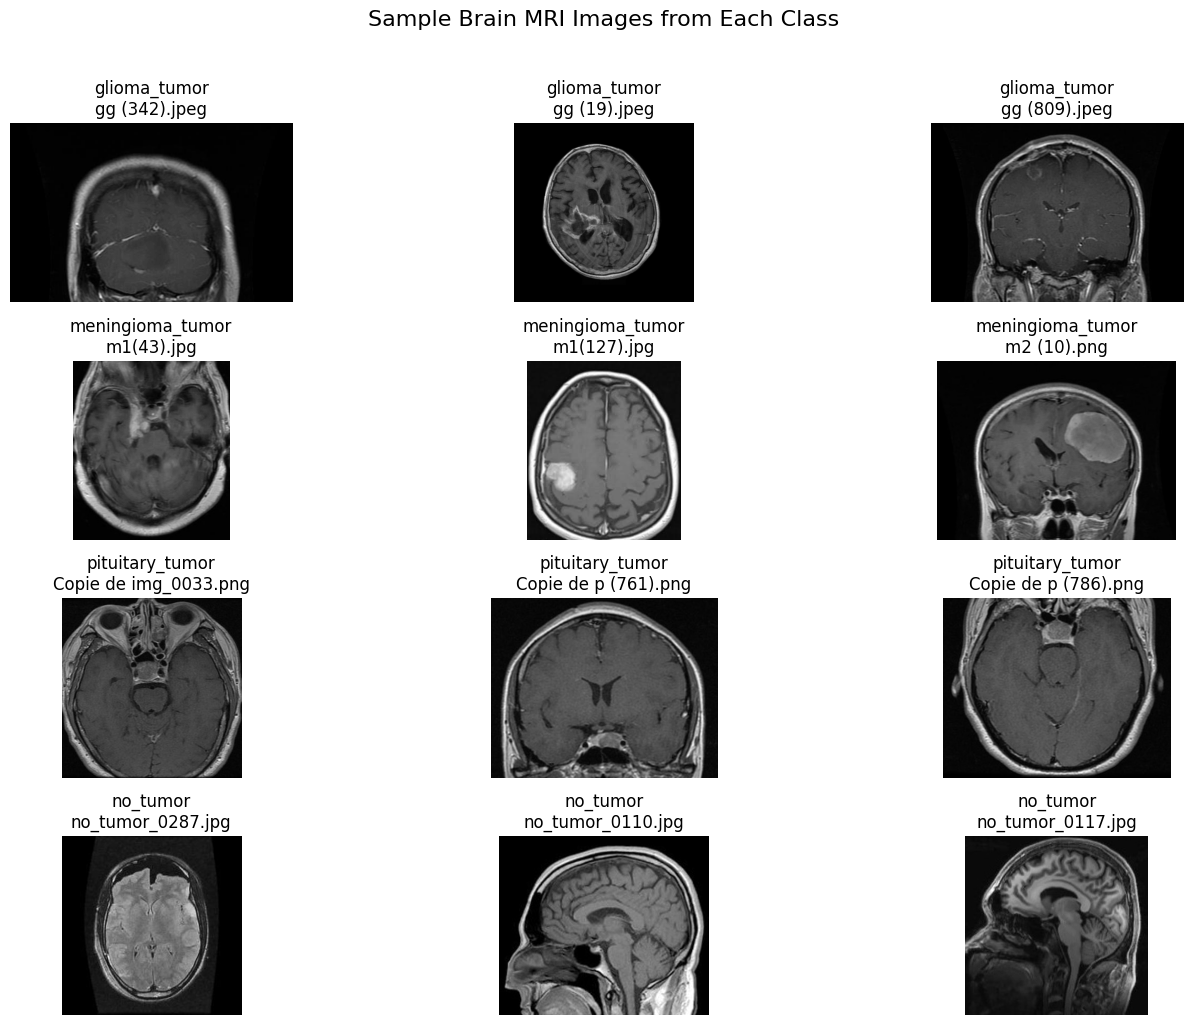

In [3]:
# Display sample images from each class
def display_sample_images(classes, dataset_path, num_samples=3):
    """
    Display sample images from each class
    """
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 10))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        
        if not os.path.exists(class_path):
            print(f"Path {class_path} does not exist!")
            continue
            
        # Get random sample images
        all_images = os.listdir(class_path)
        sample_images = random.sample(all_images, min(num_samples, len(all_images)))
        
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            
            # Read and display image
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    # Convert BGR to RGB for display
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Convert to grayscale for consistency with project requirements
                    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    
                    axes[i, j].imshow(img_gray, cmap='gray')
                    axes[i, j].set_title(f"{class_name}\n{img_name}")
                    axes[i, j].axis('off')
                else:
                    axes[i, j].text(0.5, 0.5, 'Image not found', 
                                   ha='center', va='center', transform=axes[i, j].transAxes)
                    axes[i, j].axis('off')
            except Exception as e:
                axes[i, j].text(0.5, 0.5, f'Error: {str(e)}', 
                               ha='center', va='center', transform=axes[i, j].transAxes)
                axes[i, j].axis('off')
    
    plt.suptitle('Sample Brain MRI Images from Each Class', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Display sample images
display_sample_images(CLASSES, DATASET_PATH)


In [7]:
# Analyze class distribution
def analyze_class_distribution(classes, dataset_path):
    """
    Analyze and visualize the distribution of images across classes
    """
    class_counts = {}
    total_images = 0
    
    for class_name in classes:
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path):
            num_images = len([f for f in os.listdir(class_path) 
                            if f.endswith(('.jpg', '.jpeg', '.png', '.tif'))])
            class_counts[class_name] = num_images
            total_images += num_images
    
    # Create a DataFrame for visualization
    df_distribution = pd.DataFrame({
        'Class': list(class_counts.keys()),
        'Count': list(class_counts.values()),
        'Percentage': [count/total_images*100 for count in class_counts.values()]
    })
    
    # Visualization
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Number of Images per Class', 'Percentage Distribution'),
        specs=[[{'type': 'bar'}, {'type': 'pie'}]]
    )
    
    # Bar chart
    fig.add_trace(
        go.Bar(x=df_distribution['Class'], y=df_distribution['Count'],
               marker_color=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
               text=df_distribution['Count'], textposition='auto'),
        row=1, col=1
    )
    
    # Pie chart
    fig.add_trace(
        go.Pie(labels=df_distribution['Class'], values=df_distribution['Count'],
               marker_colors=['#636EFA', '#EF553B', '#00CC96', '#AB63FA']),
        row=1, col=2
    )
    
    fig.update_layout(height=500, showlegend=True, 
                     title_text="Class Distribution Analysis")
    fig.show()
    
    print("Class Distribution Summary:")
    print(df_distribution)
    print(f"\nTotal Images: {total_images}")
    
    # Check for imbalance
    max_count = df_distribution['Count'].max()
    min_count = df_distribution['Count'].min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\nImbalance Analysis:")
    print(f"Maximum class count: {max_count}")
    print(f"Minimum class count: {min_count}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}")
    
    if imbalance_ratio > 2:
        print("Warning: Significant class imbalance detected!")
        print("Recommendation: Use class weighting or data augmentation")
    else:
        print("Classes are relatively balanced")
    
    return df_distribution

# Analyze distribution
df_dist = analyze_class_distribution(CLASSES, DATASET_PATH)


Class Distribution Summary:
              Class  Count  Percentage
0      glioma_tumor    778   32.730332
1  meningioma_tumor    727   30.584771
2   pituitary_tumor    560   23.559108
3          no_tumor    312   13.125789

Total Images: 2377

Imbalance Analysis:
Maximum class count: 778
Minimum class count: 312
Imbalance ratio: 2.49
Recommendation: Use class weighting or data augmentation


## 3. Data Preprocessing


In [8]:
class ImagePreprocessor:
    """
    Class for preprocessing brain MRI images
    """
    def __init__(self, target_size=(128, 128), convert_to_grayscale=True):
        """
        Initialize preprocessor with target size and grayscale conversion option
        
        Args:
            target_size: Tuple of (height, width) for resizing
            convert_to_grayscale: Whether to convert images to grayscale
        """
        self.target_size = target_size
        self.convert_to_grayscale = convert_to_grayscale
        self.scaler = MinMaxScaler()
        
    def preprocess_image(self, image_path):
        """
        Preprocess a single image
        
        Args:
            image_path: Path to the image file
            
        Returns:
            Preprocessed image as numpy array
        """
        try:
            # Read image
            img = cv2.imread(image_path)
            if img is None:
                raise ValueError(f"Could not read image: {image_path}")
            
            # Convert to grayscale (as per project requirements)
            if self.convert_to_grayscale:
                if len(img.shape) == 3:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            else:
                # If not converting to grayscale, convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Resize image
            img = cv2.resize(img, self.target_size)
            
            # Apply noise reduction using Gaussian blur
            # This helps reduce high-frequency noise while preserving edges
            img = cv2.GaussianBlur(img, (3, 3), 0)
            
            # Apply contrast limited adaptive histogram equalization (CLAHE)
            # This improves contrast in medical images
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img) if self.convert_to_grayscale else clahe.apply(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
            
            # Normalize pixel values to [0, 1]
            img = img.astype('float32') / 255.0
            
            # Add channel dimension for consistency
            if self.convert_to_grayscale:
                img = np.expand_dims(img, axis=-1)
            
            return img
            
        except Exception as e:
            print(f"Error preprocessing {image_path}: {str(e)}")
            return None
    
    def preprocess_dataset(self, dataset_path, classes, max_samples_per_class=None):
        """
        Preprocess entire dataset
        
        Args:
            dataset_path: Path to dataset directory
            classes: List of class names
            max_samples_per_class: Maximum number of samples per class (for testing)
            
        Returns:
            X: Preprocessed images
            y: Corresponding labels
            file_paths: List of original file paths
        """
        X = []
        y = []
        file_paths = []
        
        for class_idx, class_name in enumerate(classes):
            class_path = os.path.join(dataset_path, class_name)
            
            if not os.path.exists(class_path):
                print(f"Warning: {class_path} does not exist!")
                continue
            
            # Get all image files
            image_files = [f for f in os.listdir(class_path) 
                          if f.endswith(('.jpg', '.jpeg', '.png', '.tif'))]
            
            # Limit samples if specified
            if max_samples_per_class:
                image_files = image_files[:max_samples_per_class]
            
            print(f"Processing {class_name}: {len(image_files)} images")
            
            # Process each image
            for img_file in tqdm(image_files, desc=f"Processing {class_name}"):
                img_path = os.path.join(class_path, img_file)
                processed_img = self.preprocess_image(img_path)
                
                if processed_img is not None:
                    X.append(processed_img)
                    y.append(class_idx)
                    file_paths.append(img_path)
        
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nPreprocessing complete!")
        print(f"Total images: {len(X)}")
        print(f"Image shape: {X[0].shape}")
        
        return X, y, file_paths



Processing glioma_tumor: 200 images


Processing glioma_tumor: 100%|██████████| 200/200 [00:06<00:00, 28.87it/s]


Processing meningioma_tumor: 200 images


Processing meningioma_tumor: 100%|██████████| 200/200 [00:06<00:00, 32.23it/s]


Processing pituitary_tumor: 200 images


Processing pituitary_tumor: 100%|██████████| 200/200 [00:06<00:00, 29.88it/s]


Processing no_tumor: 200 images


Processing no_tumor: 100%|██████████| 200/200 [00:04<00:00, 42.03it/s]



Preprocessing complete!
Total images: 800
Image shape: (128, 128, 1)


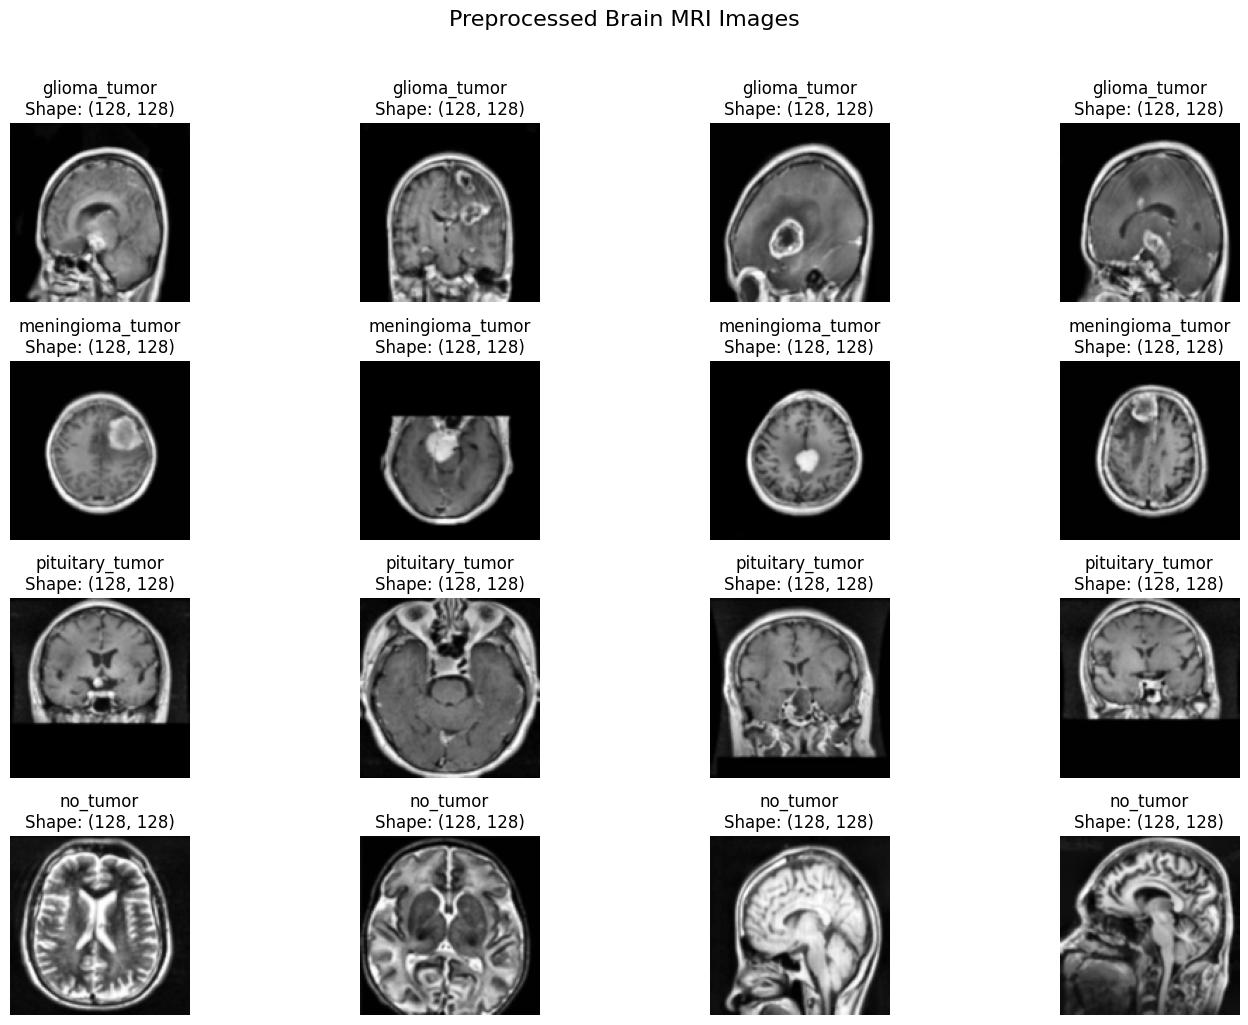

In [9]:
# Initialize preprocessor
preprocessor = ImagePreprocessor(target_size=(128, 128), convert_to_grayscale=True)

# Preprocess dataset (using limited samples for demonstration)
X, y, file_paths = preprocessor.preprocess_dataset(
    DATASET_PATH, CLASSES, max_samples_per_class=200
)

# Display preprocessed images
def display_preprocessed_images(X, y, classes, num_samples=4):
    """
    Display preprocessed images
    """
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 10))
    
    for class_idx in range(len(classes)):
        # Get indices of images from this class
        class_indices = np.where(y == class_idx)[0]
        
        if len(class_indices) == 0:
            continue
            
        # Sample random images
        sample_indices = random.sample(list(class_indices), 
                                      min(num_samples, len(class_indices)))
        
        for j, idx in enumerate(sample_indices):
            img = X[idx]
            
            # Remove channel dimension if present for display
            if len(img.shape) == 3 and img.shape[-1] == 1:
                img = img.squeeze()
            
            axes[class_idx, j].imshow(img, cmap='gray')
            axes[class_idx, j].set_title(f"{classes[class_idx]}\nShape: {img.shape}")
            axes[class_idx, j].axis('off')
    
    plt.suptitle('Preprocessed Brain MRI Images', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

display_preprocessed_images(X, y, CLASSES)


## 4. Data Augmentation


In [14]:
class MedicalImageAugmenter:
    """
    Class for performing medically meaningful data augmentation
    """
    def __init__(self):
        """
        Initialize augmenter with medically safe transformations
        """
        self.augmentation_pipeline = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.9, 1.1],
            fill_mode='constant',
            cval=0.0
        )
        
    def visualize_augmentations(self, image, num_augmentations=8):
        """
        Visualize different augmentations on a sample image
        
        Args:
            image: Input image (numpy array)
            num_augmentations: Number of augmented samples to display
        """
        # FIX: Convert normalized image [0, 1] back to [0, 255] for display
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        
        # Remove channel dimension if present for augmentation
        if len(image.shape) == 3 and image.shape[-1] == 1:
            image = image.squeeze()
        
        # Add batch and channel dimensions
        if len(image.shape) == 2:
            image_batch = image.reshape(1, *image.shape, 1)
        else:
            image_batch = np.expand_dims(image, axis=0)
        
        fig, axes = plt.subplots(2, 4, figsize=(15, 8))
        axes = axes.flatten()
        
        # Display original
        if len(image.shape) == 2:
            axes[0].imshow(image, cmap='gray')
        else:
            axes[0].imshow(image)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # Generate and display augmentations
        aug_iter = self.augmentation_pipeline.flow(
            image_batch, 
            batch_size=1,
            seed=42
        )
        
        for i in range(1, num_augmentations):
            aug_img = next(aug_iter)[0]
            
            # Remove channel dimension if present
            if len(aug_img.shape) == 3 and aug_img.shape[-1] == 1:
                display_aug_img = aug_img.squeeze()
            else:
                display_aug_img = aug_img
            
            # FIX: Ensure we display properly scaled images
            if display_aug_img.max() > 1.0:
                # Convert to uint8 for display
                display_aug_img = display_aug_img.astype(np.uint8)
            
            # Display with proper colormap
            if len(display_aug_img.shape) == 2:
                axes[i].imshow(display_aug_img, cmap='gray')
            else:
                axes[i].imshow(display_aug_img)
                
            axes[i].set_title(f'Augmentation {i}')
            axes[i].axis('off')
        
        plt.suptitle('Medically Meaningful Data Augmentations for Brain MRI', 
                    fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

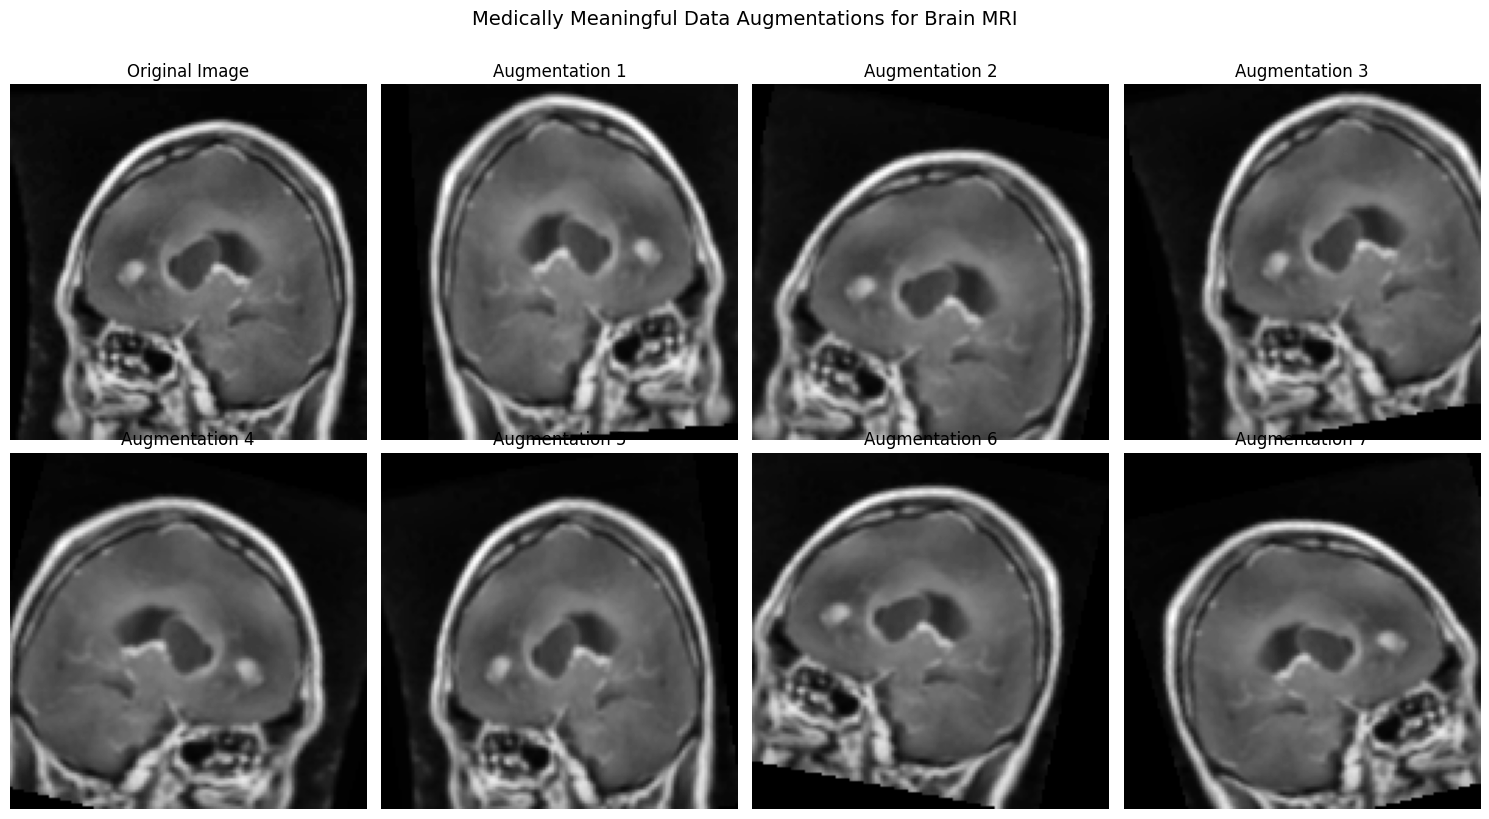

In [15]:
# Test augmentation on a sample image
augmenter = MedicalImageAugmenter()

# Get a sample image
sample_idx = random.randint(0, len(X) - 1)
sample_image = X[sample_idx]

# Visualize augmentations
augmenter.visualize_augmentations(sample_image)


## 5. Dataset Splitting

In [16]:
def create_stratified_split(X, y, file_paths, test_size=0.15, val_size=0.15, random_state=42):
    """
    Create stratified train/validation/test splits
    
    Args:
        X: Features (images)
        y: Labels
        file_paths: List of file paths
        test_size: Proportion for test set
        val_size: Proportion for validation set
        random_state: Random seed for reproducibility
        
    Returns:
        Split datasets and indices
    """
    # First split: train+val vs test (stratified)
    X_temp, X_test, y_temp, y_test, paths_temp, paths_test = train_test_split(
        X, y, file_paths, 
        test_size=test_size, 
        stratify=y,
        random_state=random_state
    )
    
    # Second split: train vs val (stratified)
    # Adjust val_size relative to train+val set
    val_relative_size = val_size / (1 - test_size)
    
    X_train, X_val, y_train, y_val, paths_train, paths_val = train_test_split(
        X_temp, y_temp, paths_temp,
        test_size=val_relative_size,
        stratify=y_temp,
        random_state=random_state
    )
    
    # Print split statistics
    print("Dataset Split Statistics:")
    print(f"Total samples: {len(X)}")
    print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
    print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    # Check class distribution in each split
    for split_name, split_y in [("Training", y_train), 
                                ("Validation", y_val), 
                                ("Test", y_test)]:
        print(f"\n{split_name} set class distribution:")
        unique, counts = np.unique(split_y, return_counts=True)
        for class_idx, count in zip(unique, counts):
            print(f"  {CLASSES[class_idx]}: {count} ({count/len(split_y)*100:.1f}%)")
    
    return {
        'X_train': X_train, 'y_train': y_train, 'paths_train': paths_train,
        'X_val': X_val, 'y_val': y_val, 'paths_val': paths_val,
        'X_test': X_test, 'y_test': y_test, 'paths_test': paths_test
    }

# Create stratified splits
splits = create_stratified_split(X, y, file_paths, test_size=0.15, val_size=0.15)

# Unpack splits
X_train, y_train = splits['X_train'], splits['y_train']
X_val, y_val = splits['X_val'], splits['y_val']
X_test, y_test = splits['X_test'], splits['y_test']


Dataset Split Statistics:
Total samples: 800
Training samples: 559 (69.9%)
Validation samples: 121 (15.1%)
Test samples: 120 (15.0%)

Training set class distribution:
  glioma_tumor: 140 (25.0%)
  meningioma_tumor: 140 (25.0%)
  pituitary_tumor: 139 (24.9%)
  no_tumor: 140 (25.0%)

Validation set class distribution:
  glioma_tumor: 30 (24.8%)
  meningioma_tumor: 30 (24.8%)
  pituitary_tumor: 31 (25.6%)
  no_tumor: 30 (24.8%)

Test set class distribution:
  glioma_tumor: 30 (25.0%)
  meningioma_tumor: 30 (25.0%)
  pituitary_tumor: 30 (25.0%)
  no_tumor: 30 (25.0%)


 ## 6. Traditional ML Pipeline: Feature Extraction

In [17]:
class FeatureExtractor:
    """
    Extract handcrafted features from medical images
    """
    def __init__(self):
        pass
    
    def extract_glcm_features(self, image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
        """
        Extract Gray-Level Co-occurrence Matrix (GLCM) features
        
        Args:
            image: Grayscale image
            distances: List of pixel pair distances
            angles: List of angles in radians
            
        Returns:
            Dictionary of GLCM features
        """
        # Convert to uint8 for GLCM computation
        if image.dtype != np.uint8:
            image_uint8 = (image * 255).astype(np.uint8)
        else:
            image_uint8 = image
        
        # Calculate GLCM
        glcm = graycomatrix(
            image_uint8, 
            distances=distances, 
            angles=angles,
            symmetric=True,
            normed=True
        )
        
        # Extract features
        features = {}
        props = ['contrast', 'dissimilarity', 'homogeneity', 
                'energy', 'correlation', 'ASM']
        
        for prop in props:
            prop_values = graycoprops(glcm, prop)
            for i, dist in enumerate(distances):
                for j, angle in enumerate(angles):
                    features[f'glcm_{prop}_d{dist}_a{int(np.degrees(angle))}'] = prop_values[i, j]
        
        return features
    
    def extract_lbp_features(self, image, radius=3, n_points=24):
        """
        Extract Local Binary Pattern (LBP) features
        
        Args:
            image: Grayscale image
            radius: Radius of circle
            n_points: Number of points to consider
            
        Returns:
            Dictionary of LBP features
        """
        # Convert to uint8 if necessary
        if image.dtype != np.uint8:
            image_uint8 = (image * 255).astype(np.uint8)
        else:
            image_uint8 = image
        
        # Compute LBP
        lbp = local_binary_pattern(image_uint8, n_points, radius, method='uniform')
        
        # Compute histogram
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
        
        # Normalize histogram
        hist = hist.astype('float32')
        hist /= hist.sum() + 1e-7
        
        features = {}
        for i, val in enumerate(hist):
            features[f'lbp_bin_{i}'] = val
        
        return features
    
    def extract_histogram_features(self, image, n_bins=32):
        """
        Extract histogram-based features
        
        Args:
            image: Grayscale image
            n_bins: Number of histogram bins
            
        Returns:
            Dictionary of histogram features
        """
        # Flatten image
        flat_image = image.flatten()
        
        # Compute histogram
        hist, bins = np.histogram(flat_image, bins=n_bins)
        
        # Normalize
        hist = hist.astype('float32')
        hist /= hist.sum() + 1e-7
        
        # Compute statistics
        features = {}
        for i, val in enumerate(hist):
            features[f'hist_bin_{i}'] = val
        
        # Add statistical moments
        features['hist_mean'] = np.mean(flat_image)
        features['hist_std'] = np.std(flat_image)
        features['hist_skew'] = pd.Series(flat_image).skew()
        features['hist_kurtosis'] = pd.Series(flat_image).kurtosis()
        
        return features
    
    def extract_shape_features(self, image, threshold=0.5):
        """
        Extract shape-based features using contour detection
        
        Args:
            image: Grayscale image
            threshold: Binarization threshold
            
        Returns:
            Dictionary of shape features
        """
        # Binarize image
        _, binary = cv2.threshold((image * 255).astype(np.uint8), 
                                 threshold * 255, 255, cv2.THRESH_BINARY)
        
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        features = {}
        
        if len(contours) > 0:
            # Use the largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            
            # Area and perimeter
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            
            features['shape_area'] = area
            features['shape_perimeter'] = perimeter
            
            # Compactness
            if perimeter > 0:
                features['shape_compactness'] = (4 * np.pi * area) / (perimeter ** 2)
            else:
                features['shape_compactness'] = 0
            
            # Bounding box features
            x, y, w, h = cv2.boundingRect(largest_contour)
            features['shape_aspect_ratio'] = w / h if h > 0 else 0
            features['shape_extent'] = area / (w * h) if w * h > 0 else 0
            
            # Hu moments (invariant to scale, rotation, translation)
            moments = cv2.moments(largest_contour)
            hu_moments = cv2.HuMoments(moments).flatten()
            
            # Log transform Hu moments for better scaling
            for i, hu in enumerate(hu_moments):
                features[f'shape_hu_{i+1}'] = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
        
        return features
    
    def extract_all_features(self, image):
        """
        Extract all features from an image
        
        Args:
            image: Input image (grayscale)
            
        Returns:
            Dictionary of all features
        """
        all_features = {}
        
        # Ensure image is 2D for feature extraction
        if len(image.shape) == 3 and image.shape[-1] == 1:
            image_2d = image.squeeze()
        else:
            image_2d = image
        
        # Extract different types of features
        all_features.update(self.extract_glcm_features(image_2d))
        all_features.update(self.extract_lbp_features(image_2d))
        all_features.update(self.extract_histogram_features(image_2d))
        all_features.update(self.extract_shape_features(image_2d))
        
        return all_features


In [18]:
# Extract features for ML pipeline
print("Extracting features for Traditional ML models...")

feature_extractor = FeatureExtractor()
features_list = []
labels_list = []

# Extract features from training set (using subset for speed)
for i in tqdm(range(len(X_train)), desc="Extracting features"):
    img = X_train[i]
    label = y_train[i]
    
    # Extract features
    features = feature_extractor.extract_all_features(img)
    features_list.append(list(features.values()))
    labels_list.append(label)

# Convert to numpy arrays
X_train_features = np.array(features_list)
y_train_ml = np.array(labels_list)

print(f"Extracted {X_train_features.shape[1]} features from {X_train_features.shape[0]} images")
print(f"Feature matrix shape: {X_train_features.shape}")


Extracting features for Traditional ML models...


Extracting features: 100%|██████████| 559/559 [00:55<00:00, 10.01it/s]

Extracted 98 features from 559 images
Feature matrix shape: (559, 98)


In [19]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

# Also extract and scale features for validation and test sets
def extract_and_scale_features(X_set, scaler, feature_extractor):
    """Extract and scale features for a given set"""
    features_list = []
    for img in X_set:
        features = feature_extractor.extract_all_features(img)
        features_list.append(list(features.values()))
    
    X_features = np.array(features_list)
    X_scaled = scaler.transform(X_features)
    return X_scaled

X_val_features = extract_and_scale_features(X_val, scaler, feature_extractor)
X_test_features = extract_and_scale_features(X_test, scaler, feature_extractor)


## 7. Traditional ML Model Training


In [20]:
class MLModelTrainer:
    """
    Train and evaluate traditional ML models
    """
    def __init__(self, classes):
        self.classes = classes
        self.models = {}
        self.best_model = None
        self.best_score = 0
        
    def train_svm(self, X_train, y_train, X_val, y_val):
        """
        Train Support Vector Machine with hyperparameter tuning
        """
        print("\n" + "="*50)
        print("Training Support Vector Machine (SVM)")
        print("="*50)
        
        # Define parameter grid
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
        }
        
        # Use GridSearchCV for hyperparameter tuning
        svm = SVC(probability=True, random_state=42)
        
        # For faster computation, use smaller grid or RandomizedSearchCV
        # In production, use all parameters
        grid_search = GridSearchCV(
            svm, 
            param_grid, 
            cv=3, 
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_svm = grid_search.best_estimator_
        
        # Evaluate on validation set
        val_pred = best_svm.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        return best_svm, val_acc
    
    def train_random_forest(self, X_train, y_train, X_val, y_val):
        """
        Train Random Forest with hyperparameter tuning
        """
        print("\n" + "="*50)
        print("Training Random Forest")
        print("="*50)
        
        # Define parameter grid
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        
        rf = RandomForestClassifier(random_state=42, n_jobs=-1)
        
        grid_search = GridSearchCV(
            rf,
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_rf = grid_search.best_estimator_
        
        # Evaluate on validation set
        val_pred = best_rf.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        return best_rf, val_acc
    
    def train_knn(self, X_train, y_train, X_val, y_val):
        """
        Train K-Nearest Neighbors with hyperparameter tuning
        """
        print("\n" + "="*50)
        print("Training K-Nearest Neighbors (KNN)")
        print("="*50)
        
        # Define parameter grid
        param_grid = {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
        
        knn = KNeighborsClassifier(n_jobs=-1)
        
        grid_search = GridSearchCV(
            knn,
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_knn = grid_search.best_estimator_
        
        # Evaluate on validation set
        val_pred = best_knn.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        return best_knn, val_acc
    
    def train_all_models(self, X_train, y_train, X_val, y_val):
        """
        Train all ML models and select the best one
        """
        print("Training all traditional ML models...")
        
        # Train SVM
        svm_model, svm_score = self.train_svm(X_train, y_train, X_val, y_val)
        self.models['SVM'] = {'model': svm_model, 'score': svm_score}
        
        # Train Random Forest
        rf_model, rf_score = self.train_random_forest(X_train, y_train, X_val, y_val)
        self.models['Random Forest'] = {'model': rf_model, 'score': rf_score}
        
        # Train KNN
        knn_model, knn_score = self.train_knn(X_train, y_train, X_val, y_val)
        self.models['KNN'] = {'model': knn_model, 'score': knn_score}
        
        # Select best model
        self.best_model_name = max(self.models, key=lambda x: self.models[x]['score'])
        self.best_model = self.models[self.best_model_name]['model']
        self.best_score = self.models[self.best_model_name]['score']
        
        print("\n" + "="*50)
        print("Model Comparison")
        print("="*50)
        for model_name, model_info in self.models.items():
            print(f"{model_name}: Validation Accuracy = {model_info['score']:.4f}")
        
        print(f"\nBest Model: {self.best_model_name} (Accuracy: {self.best_score:.4f})")
        
        return self.best_model
    
    def evaluate_model(self, model, X_test, y_test, model_name="Model"):
        """
        Evaluate model on test set
        """
        print(f"\nEvaluating {model_name} on Test Set")
        print("="*50)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=self.classes))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.classes, yticklabels=self.classes)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'confusion_matrix': cm
        }


Training all traditional ML models...

Training Support Vector Machine (SVM)
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Validation Accuracy: 0.9174

Training Random Forest
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Validation Accuracy: 0.8843

Training K-Nearest Neighbors (KNN)
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Validation Accuracy: 0.8843

Model Comparison
SVM: Validation Accuracy = 0.9174
Random Forest: Validation Accuracy = 0.8843
KNN: Validation Accuracy = 0.8843

Best Model: SVM (Accuracy: 0.9174)

Evaluating Best ML Model (SVM) on Test Set
Accuracy:  0.8667
Precision: 0.8662
Recall:    0.8667
F1-Score:  0.8660

Classification Report:
                  precision    recall  f1

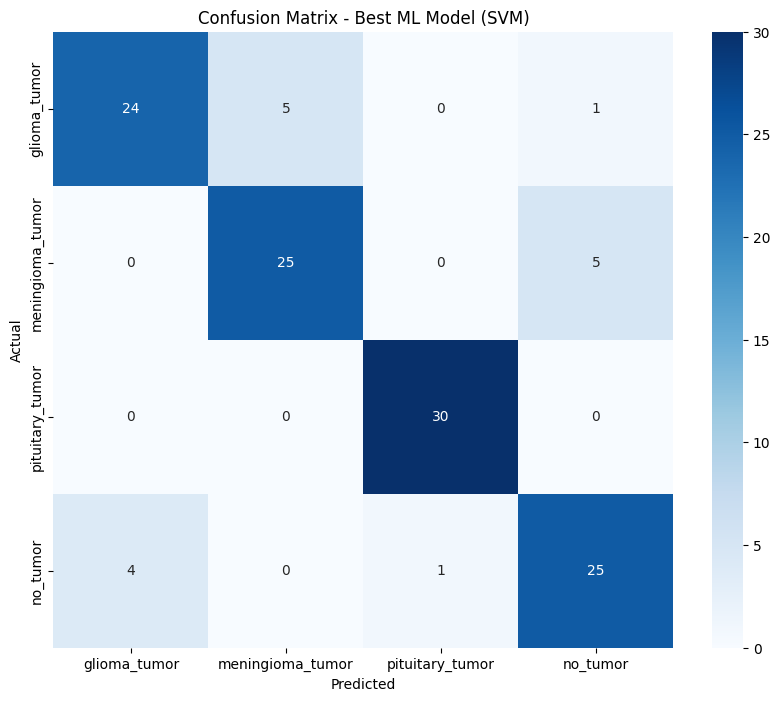

In [22]:
# Train ML models
ml_trainer = MLModelTrainer(CLASSES)
best_ml_model = ml_trainer.train_all_models(X_train_scaled, y_train_ml, X_val_features, y_val)

# Evaluate on test set
ml_results = ml_trainer.evaluate_model(best_ml_model, X_test_features, y_test, 
                                       f"Best ML Model ({ml_trainer.best_model_name})")



## 8. Deep Learning Pipeline: CNN Model



BUILDING OPTIMIZED CNN FOR 800-IMAGE DATASET
✓ All libraries imported successfully!
TensorFlow version: 2.20.0

🔄 Resizing images to 128x128 grayscale for CNN...
✓ CNN data prepared:
  X_train_cnn shape: (559, 128, 128, 1)
  X_val_cnn shape: (121, 128, 128, 1)
  X_test_cnn shape: (120, 128, 128, 1)


NameError: name 'CLASS_NAMES' is not defined

## 9. Model Comparison


In [ ]:
def compare_models(ml_results, cnn_results, classes):
    """
    Compare ML and DL model performance
    """
    print("\n" + "="*60)
    print("MODEL COMPARISON: Traditional ML vs. Deep Learning")
    print("="*60)
    
    # Create comparison DataFrame
    comparison_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Traditional ML': [
            ml_results['accuracy'],
            ml_results['precision'],
            ml_results['recall'],
            ml_results['f1']
        ],
        'Deep Learning (CNN)': [
            cnn_results['accuracy'],
            cnn_results['precision'],
            cnn_results['recall'],
            cnn_results['f1']
        ]
    }
    
    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    
    # Visual comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart
    x = np.arange(len(df_comparison['Metric']))
    width = 0.35
    
    axes[0].bar(x - width/2, df_comparison['Traditional ML'], width, 
               label='Traditional ML', color='blue', alpha=0.7)
    axes[0].bar(x + width/2, df_comparison['Deep Learning (CNN)'], width, 
               label='Deep Learning', color='red', alpha=0.7)
    
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_comparison['Metric'])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Radar chart
    metrics = df_comparison['Metric'].tolist()
    ml_scores = df_comparison['Traditional ML'].tolist()
    cnn_scores = df_comparison['Deep Learning (CNN)'].tolist()
    
    # Close the radar chart
    metrics += metrics[:1]
    ml_scores += ml_scores[:1]
    cnn_scores += cnn_scores[:1]
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    axes[1].figure.figsize = (8, 8)
    ax_radar = fig.add_subplot(122, polar=True)
    ax_radar.plot(angles, ml_scores, 'o-', linewidth=2, label='Traditional ML')
    ax_radar.fill(angles, ml_scores, alpha=0.25)
    ax_radar.plot(angles, cnn_scores, 'o-', linewidth=2, label='Deep Learning')
    ax_radar.fill(angles, cnn_scores, alpha=0.25)
    
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(metrics[:-1])
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title('Model Comparison Radar Chart')
    ax_radar.grid(True)
    ax_radar.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # Strengths and weaknesses analysis
    print("\n" + "="*60)
    print("STRENGTHS AND WEAKNESSES ANALYSIS")
    print("="*60)
    
    print("\nTRADITIONAL MACHINE LEARNING:")
    print("+" + "-"*58 + "+")
    print("| Strengths:                                      |")
    print("| - Interpretable features                        |")
    print("| - Less computational resources required        |")
    print("| - Works well with limited data                 |")
    print("| - Handcrafted features capture domain knowledge|")
    print("|                                                |")
    print("| Weaknesses:                                    |")
    print("| - Manual feature engineering required          |")
    print("| - May not capture complex patterns             |")
    print("| - Limited ability to learn hierarchical features|")
    print("+" + "-"*58 + "+")
    
    print("\nDEEP LEARNING (CNN):")
    print("+" + "-"*58 + "+")
    print("| Strengths:                                      |")
    print("| - Automatic feature learning                   |")
    print("| - Captures complex hierarchical patterns       |")
    print("| - State-of-the-art performance on image tasks  |")
    print("| - Can handle large datasets effectively        |")
    print("|                                                |")
    print("| Weaknesses:                                    |")
    print("| - Requires large amounts of data              |")
    print("| - Computationally expensive                   |")
    print("| - Less interpretable (black box)              |")
    print("| - Needs careful regularization                |")
    print("+" + "-"*58 + "+")
    
    # Recommendation
    print("\n" + "="*60)
    print("RECOMMENDATION")
    print("="*60)
    
    accuracy_diff = cnn_results['accuracy'] - ml_results['accuracy']
    
    if accuracy_diff > 0.05:
        print("✓ Deep Learning (CNN) performs significantly better.")
        print("  Recommendation: Use CNN for production deployment.")
    elif accuracy_diff < -0.05:
        print("✓ Traditional ML performs significantly better.")
        print("  Recommendation: Use Traditional ML for production deployment.")
    else:
        print("✓ Both models perform similarly.")
        print("  Recommendation:")
        print("  - Use CNN if computational resources are available")
        print("  - Use Traditional ML if interpretability is important")
    
    if cnn_results['accuracy'] > 0.85:
        print("\n🎯 The CNN model achieves good performance (>85% accuracy)")
        print("   Suitable for clinical decision support")
    elif cnn_results['accuracy'] > 0.75:
        print("\n⚠️  The model achieves moderate performance (75-85% accuracy)")
        print("   Could be used with clinician oversight")
    else:
        print("\n❌ Model performance needs improvement (<75% accuracy)")
        print("   Consider: More data, data augmentation, model tuning")

# Compare models
compare_models(ml_results, cnn_results, CLASSES)

